In [17]:
from numba import cuda, float32
import threading

import math
import numpy as np
import matplotlib.pyplot as plt
from time import time

SHARED_SIZE = 256
KSIZE = 7
RADIUS = KSIZE // 2

In [18]:
@cuda.jit(device=True)
def rgb2hsv(r, g, b):
  r = r / 255.0
  g = g / 255.0
  b = b / 255.0

  max_rgb = max(r, max(g, b))
  min_rgb = min(r, min(g, b))
  delta = max_rgb - min_rgb

  if delta == 0:
    h = 0.0
  elif max_rgb == r:
    k = (g - b) / delta
    if k < 0:
      k += 6.0
    h = 60.0 * k
  elif max_rgb == g:
    h = 60.0 * (((b - r) / delta) + 2.0)
  else:
    h = 60.0 * (((r - g) / delta) + 4.0)

  if max_rgb == 0:
    s = 0.0
  else:
    s = delta / max_rgb

  v = max_rgb

  return h, s, v


@cuda.jit(device=True)
def hsv2rgb(h, s, v):
  if h < 0:
    h += 360.0
  if h >= 360.0:
    h -= 360.0

  d = h / 60.0
  hi = int(d)
  f = d - hi

  l = v * (1.0 - s)
  m = v * (1.0 - f * s)
  n = v * (1.0 - (1.0 - f) * s)

  if hi == 0:
    r = v
    g = n
    b = l
  elif hi == 1:
    r = m
    g = v
    b = l
  elif hi == 2:
    r = l
    g = v
    b = n
  elif hi == 3:
    r = l
    g = m
    b = v
  elif hi == 4:
    r = n
    g = l
    b = v
  else:
    r = v
    g = l
    b = m

  return int(r * 255.0 + 0.5), int(g * 255.0 + 0.5), int(b * 255.0 + 0.5)


@cuda.jit
def rgb2hsv_gpu_2d(src, dst):
  x = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
  y = cuda.threadIdx.y + cuda.blockIdx.y * cuda.blockDim.y

  h, w, _ = src.shape
  if x < w and y < h:
    hh, ss, vv = rgb2hsv(src[y, x, 0], src[y, x, 1], src[y, x, 2])
    dst[y, x, 0] = hh
    dst[y, x, 1] = ss
    dst[y, x, 2] = vv


@cuda.jit
def hsv2rgb_gpu_2d(src, dst):
  x = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
  y = cuda.threadIdx.y + cuda.blockIdx.y * cuda.blockDim.y

  h, w, _ = src.shape
  if x < w and y < h:
    r, g, b = hsv2rgb(src[y, x, 0], src[y, x, 1], src[y, x, 2])
    dst[y, x, 0] = r
    dst[y, x, 1] = g
    dst[y, x, 2] = b

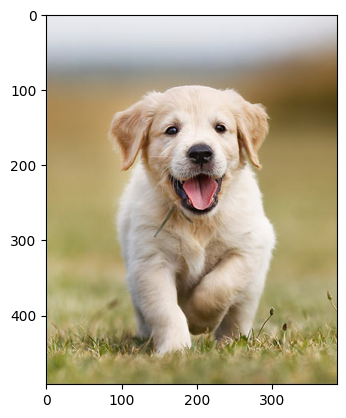

In [19]:
img_src = "/content/drive/MyDrive/DATA/HPC/image.jpg"
img=plt.imread(img_src, format=None)
plt.imshow(img)
plt.show()

rgb2hsv time = 0.245101s
H: 0.0 359.4545454545455
S: 0.0 1.0
V: 0.0 1.0


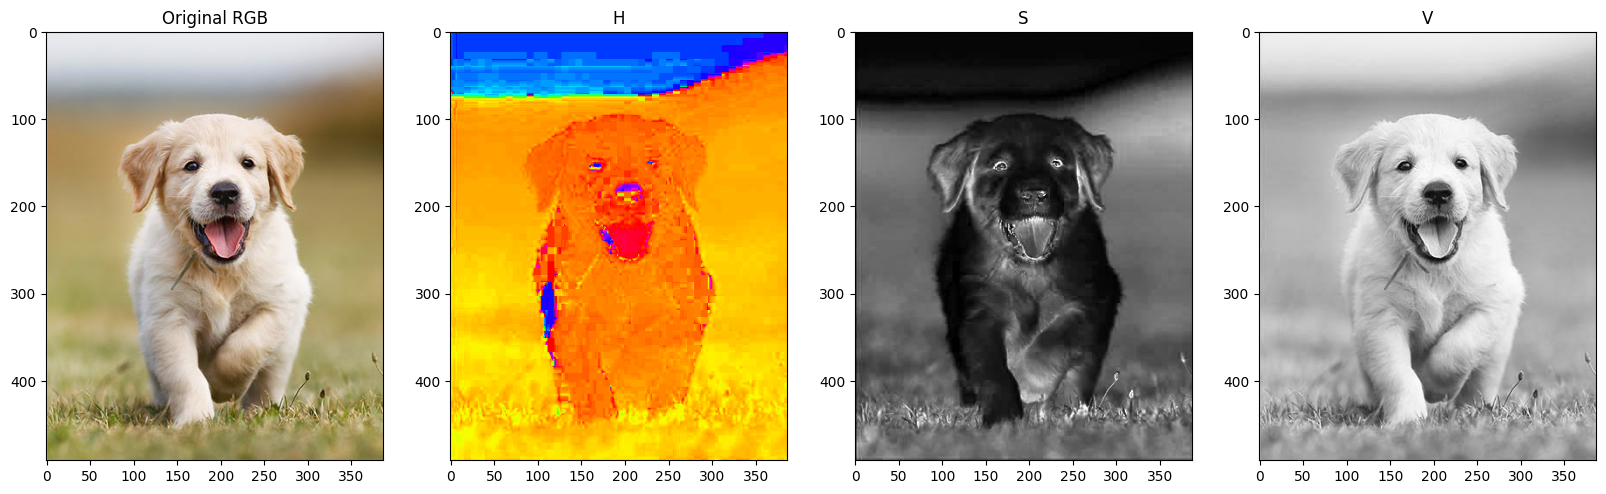

In [20]:
h, w, _ = img.shape

threads = (16, 16)
blocks = (math.ceil(w / threads[0]), math.ceil(h / threads[1]))

d_img = cuda.to_device(img)
d_hsv = cuda.device_array((h, w, 3), np.float64)

start = time()
rgb2hsv_gpu_2d[blocks, threads](d_img, d_hsv)
cuda.synchronize()
end = time()

hsv_img = d_hsv.copy_to_host()

print(f"rgb2hsv time = {end - start:.6f}s")
print("H:", hsv_img[:, :, 0].min(), hsv_img[:, :, 0].max())
print("S:", hsv_img[:, :, 1].min(), hsv_img[:, :, 1].max())
print("V:", hsv_img[:, :, 2].min(), hsv_img[:, :, 2].max())

fig, ax = plt.subplots(1, 4, figsize=(20, 6))
ax[0].imshow(img)
ax[0].set_title('Original RGB')
ax[1].imshow(hsv_img[:, :, 0] / 360.0, cmap='hsv', vmin=0, vmax=1)
ax[1].set_title('H')
ax[2].imshow(hsv_img[:, :, 1], cmap='gray', vmin=0, vmax=1)
ax[2].set_title('S')
ax[3].imshow(hsv_img[:, :, 2], cmap='gray', vmin=0, vmax=1)
ax[3].set_title('V')
plt.show()

hsv2rgb time = 0.604120s
Max diff: 0
Mean diff: 0.0
Pixel offset: 0 / 190404
Same: True


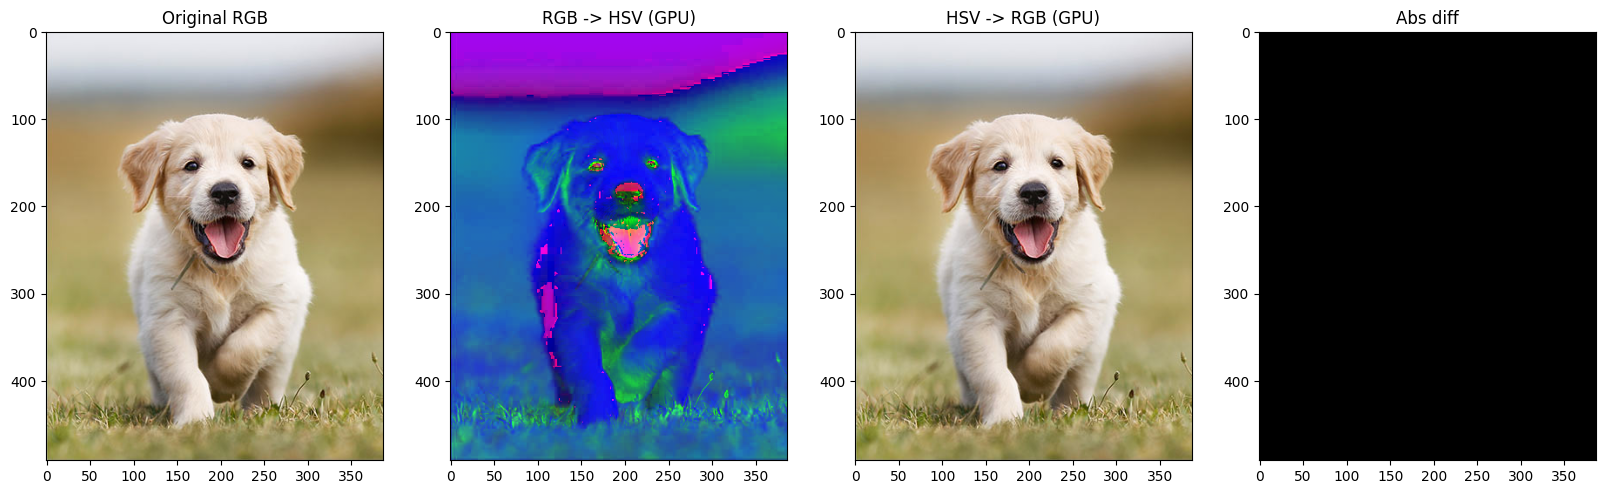

In [22]:
d_rgb = cuda.device_array((h, w, 3), np.uint8)

start = time()
hsv2rgb_gpu_2d[blocks, threads](d_hsv, d_rgb)
cuda.synchronize()
end = time()

rgb_back = d_rgb.copy_to_host()
print(f"hsv2rgb time = {end - start:.6f}s")

diff = np.abs(img.astype(np.int32) - rgb_back.astype(np.int32))

print("Max diff:", diff.max())
print("Mean diff:", diff.mean())
print("Pixel offset:", np.count_nonzero(diff.any(axis=2)), "/", h * w)
print("Same:", np.array_equal(img, rgb_back))

hsv_vis = np.stack([
  hsv_img[:, :, 0] / 360.0,
  hsv_img[:, :, 1],
  hsv_img[:, :, 2]
], axis=2)
hsv_vis = np.clip(hsv_vis, 0, 1)

fig, ax = plt.subplots(1, 4, figsize=(20, 6))
ax[0].imshow(img)
ax[0].set_title('Original RGB')
ax[1].imshow(hsv_vis)
ax[1].set_title('RGB -> HSV (GPU)')
ax[2].imshow(rgb_back)
ax[2].set_title('HSV -> RGB (GPU)')
ax[3].imshow(diff.max(axis=2), cmap='gray')
ax[3].set_title('Abs diff')
plt.show()